# RAGRoute 재현 — Colab 실행 노트북

**실행 전 준비사항**
- 런타임: GPU (A100 권장)
- Colab Secrets에 `HF_TOKEN` 저장
- Cell 1의 `REPO_URL`을 본인 repo URL로 수정

**실행 순서**: Cell 1 → 2 → 3 → 4 → 5 → 6 → (7→8→9 선택)

In [ ]:
import os, sys, shutil, subprocess, torch
from google.colab import drive, userdata

# ⚠️ 여기만 수정
REPO_URL = 'https://github.com/ByoungjaeMin/ragroute_recreation.git'

assert torch.cuda.is_available(), 'GPU 없음: 런타임 > 런타임 유형 변경'
print(f'GPU: {torch.cuda.get_device_name(0)}')

drive.mount('/content/drive')
DRIVE_ROOT = '/content/drive/MyDrive/ragroute'

REPO_PATH = '/content/ragroute_recreation'
if not os.path.isdir(REPO_PATH):
    subprocess.run(['git', 'clone', REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(['git', '-C', REPO_PATH, 'pull', '--ff-only'])
os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH)

subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)

hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = os.environ['HUGGING_FACE_HUB_TOKEN'] = hf_token

def _link(local, sub):
    d = f'{DRIVE_ROOT}/{sub}'; os.makedirs(d, exist_ok=True)
    parent = os.path.dirname(local)
    if parent: os.makedirs(parent, exist_ok=True)
    if os.path.islink(local): os.remove(local)
    elif os.path.isdir(local): shutil.rmtree(local)
    os.symlink(d, local)

for local, sub in [('data/embeddings','embeddings'), ('data/processed','processed'),
                   ('data/stats','stats'), ('data/raw','raw'),
                   ('checkpoints','checkpoints'), ('results','results')]:
    _link(local, sub)

print('✅ 환경 설정 완료')

GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive
✅ 환경 설정 완료


In [ ]:
import os, subprocess, shutil, json
from huggingface_hub import snapshot_download

os.makedirs('data/raw/mirage', exist_ok=True)

# textbooks — HuggingFace (chunk/ → data/raw/mirage/textbooks/)
tb_dst = 'data/raw/mirage/textbooks'
if os.path.isdir(tb_dst) and os.listdir(tb_dst):
    print('[SKIP] textbooks')
else:
    print('[DOWN] textbooks ...')
    tmp = '/tmp/textbooks_hf'
    snapshot_download('MedRAG/textbooks', repo_type='dataset', local_dir=tmp,
                      allow_patterns=['chunk/*'], token=os.environ.get('HF_TOKEN'))
    shutil.copytree(f'{tmp}/chunk', tb_dst)
    print(f'  완료: {len(os.listdir(tb_dst))} files')

# statpearls — NCBI FTP + MedRAG statpearls.py
sp_dst = 'data/raw/mirage/statpearls'
if os.path.isdir(sp_dst) and os.listdir(sp_dst):
    print('[SKIP] statpearls')
else:
    medrag = '/tmp/MedRAG_toolkit'
    if not os.path.isdir(medrag):
        subprocess.run(['git', 'clone', '-q', 'https://github.com/Teddy-XiongGZ/MedRAG.git', medrag], check=True)

    ncbi_tar = f'{medrag}/corpus/statpearls/statpearls_NBK430685.tar.gz'
    os.makedirs(os.path.dirname(ncbi_tar), exist_ok=True)

    # 손상된 파일 자동 감지 및 재다운로드
    MIN_SIZE = 1_500_000_000  # 1.5GB
    def _tar_valid(path):
        r = subprocess.run(['tar', 'tzf', path], capture_output=True)
        return r.returncode == 0
    if os.path.exists(ncbi_tar) and (os.path.getsize(ncbi_tar) < MIN_SIZE or not _tar_valid(ncbi_tar)):
        print('[WARN] 손상된 tar.gz 감지 → 삭제 후 재다운로드')
        os.remove(ncbi_tar)
    if not os.path.exists(ncbi_tar):
        print('[DOWN] statpearls NCBI FTP (~1.7GB) ...')
        subprocess.run(['wget', '--show-progress', '-c', '-O', ncbi_tar,
                        'https://ftp.ncbi.nlm.nih.gov/pub/litarch/3d/12/statpearls_NBK430685.tar.gz'], check=True)
        if os.path.getsize(ncbi_tar) < MIN_SIZE:
            raise RuntimeError(f'statpearls 다운로드 실패: {os.path.getsize(ncbi_tar):,} bytes (최소 {MIN_SIZE:,} 필요)')

    nxml = f'{medrag}/corpus/statpearls/statpearls_NBK430685'
    if not os.path.isdir(nxml):
        print('[UNPACK] tar 압축 해제 중 ...')
        subprocess.run(['tar', 'xzf', ncbi_tar, '-C', os.path.dirname(nxml)], check=True)

    chunk_out = f'{medrag}/corpus/statpearls/chunk'
    if not (os.path.isdir(chunk_out) and os.listdir(chunk_out)):
        print('[PROC] statpearls.py (~20분) ...')
        subprocess.run(['python3', 'src/data/statpearls.py'], cwd=medrag, check=True)

    shutil.copytree(chunk_out, sp_dst)
    print(f'  완료: {len(os.listdir(sp_dst))} files')

# Wikipedia 1M 스니펫 생성 (MMLU용)
SNIPPETS_PATH = 'data/raw/wikipedia_1m/snippets.jsonl'
if os.path.exists(SNIPPETS_PATH):
    import subprocess as _sp
    n = int(_sp.run(['wc','-l',SNIPPETS_PATH], capture_output=True, text=True).stdout.split()[0])
    print(f'[SKIP] Wikipedia snippets ({n:,}줄)')
else:
    print('[GEN] Wikipedia 1M 스니펫 생성 중 (수십 분 소요)...')
    from datasets import load_dataset
    os.makedirs('data/raw/wikipedia_1m', exist_ok=True)
    ds = load_dataset('wikimedia/wikipedia', '20231101.en', split='train', streaming=True)
    count = 0; target = 1_000_000
    with open(SNIPPETS_PATH, 'w') as f:
        for article in ds:
            words = article['text'].split()
            for i in range(0, len(words), 100):
                f.write(json.dumps({'title': article['title'], 'text': ' '.join(words[i:i+100])}) + '\n')
                count += 1
                if count >= target: break
            if count >= target: break
    print(f'  완료: {count:,} 스니펫')

print('✅ 데이터 준비 완료')

[SKIP] textbooks
[SKIP] statpearls
[SKIP] Wikipedia snippets (1,000,000줄)
✅ 데이터 준비 완료


In [ ]:
# medrag: MedCPT-Article-Encoder (textbooks/statpearls) + MedCPT-Query-Encoder (query)
# A100 기준 ~30분
!python scripts/02_build_embeddings.py --dataset medrag
!python scripts/02_build_embeddings.py --dataset mmlu

=== Building medrag embeddings → /content/ragroute_recreation/data/embeddings/mirage ===
config.json: 100% 608/608 [00:00<00:00, 3.80MB/s]
tokenizer_config.json: 1.49kB [00:00, 2.86MB/s]
vocab.txt: 226kB [00:00, 80.8MB/s]
tokenizer.json: 706kB [00:00, 145MB/s]
added_tokens.json: 100% 74.0/74.0 [00:00<00:00, 528kB/s]
special_tokens_map.json: 100% 125/125 [00:00<00:00, 804kB/s]
model.safetensors: 100% 438M/438M [00:03<00:00, 145MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 4468.38it/s]
config.json: 100% 608/608 [00:00<00:00, 2.76MB/s]
tokenizer_config.json: 1.49kB [00:00, 3.62MB/s]
vocab.txt: 226kB [00:00, 78.3MB/s]
tokenizer.json: 706kB [00:00, 136MB/s]
added_tokens.json: 100% 74.0/74.0 [00:00<00:00, 527kB/s]
special_tokens_map.json: 100% 125/125 [00:00<00:00, 892kB/s]
model.safetensors: 100% 438M/438M [00:05<00:00, 87.4MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 5504.05it/s]
[article] textbooks: already exists, skipping.
[article] statpearls: already exists, skipping.
[query]

In [ ]:
# medrag: IndexFlatL2 / mmlu: normalize_L2 + IndexFlatIP
!python scripts/03_build_index.py --dataset medrag
!python scripts/03_build_index.py --dataset mmlu

=== Building medrag indices → /content/ragroute_recreation/data/embeddings/mirage ===
[medrag] textbooks: index + stats already exist, skipping.
[medrag] statpearls: index + stats already exist, skipping.

Done. Next: python scripts/04_generate_train_data.py --config experiments/...
=== Building mmlu indices → /content/ragroute_recreation/data/embeddings/mmlu ===
[mmlu] cluster 0: index already exists, skipping build.
[mmlu] cluster 1: index already exists, skipping build.
[mmlu] cluster 2: index already exists, skipping build.
[mmlu] cluster 3: index already exists, skipping build.
[mmlu] cluster 4: index already exists, skipping build.
[mmlu] cluster 5: index already exists, skipping build.
[mmlu] cluster 6: index already exists, skipping build.
[mmlu] cluster 7: index already exists, skipping build.
[mmlu] cluster 8: index already exists, skipping build.
[mmlu] cluster 9: index already exists, skipping build.
[mmlu] cluster_stats.json saved (10 entries).

Done. Next: python scripts/

In [ ]:
# LABEL_K=15, medrag=L2 오름차순, mmlu=IP 내림차순, test=60%
!python scripts/04_generate_train_data.py --config experiments/mirage_top32.yaml
!python scripts/04_generate_train_data.py --config experiments/mmlu_top10.yaml

=== Stage 4: Generate training data [medrag] ===
  Loaded 2 sources: ['textbooks', 'statpearls']
  pubmedqa: 500 queries
  medqa: 1273 queries
  bioasq: 618 queries
  medmcqa: 4183 queries
  mmlu-med: 1089 queries
  Total queries: 7663, embedding shape: (7663, 768)
  Split file already exists: data/processed/mirage/train_test_split.json
  Split: train=2758, val=307, test=4598
  Loading pre-computed X/y ...
  Label distribution: pos_rate=0.7776 (11918 / 15326)
  X_train=(5516, 1538)  y_train pos=0.7725
  X_val=(614, 1538)    y_val pos=0.7655
  X_test=(9196, 1538)   y_test pos=0.7815

Done. Files saved to data/processed/mirage
Next: python scripts/05_train_router.py --config experiments/mirage_top32.yaml
=== Stage 4: Generate training data [wikipedia] ===
  Loaded 10 sources: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  mmlu: 2803 queries
  Total queries: 2803, embedding shape: (2803, 768)
  Split file already exists: data/processed/mmlu/train_test_split.json
  Split: train=1008,

In [ ]:
# 150 epoch, CyclicLR(ep<115) → StepLR(ep≥115)
# medrag best=val_auc, wikipedia best=val_f1  |  A100 기준 각 5~15분
!python scripts/05_train_router.py --config experiments/mirage_top32.yaml
!python scripts/05_train_router.py --config experiments/mmlu_top10.yaml

=== Stage 5: Train router [medrag] ===
  X_train=(5516, 1538)  pos=0.7725
  X_val  =(614, 1538)    pos=0.7655
  epoch  10/150  val_auc=0.9220  best=0.9227
  epoch  20/150  val_auc=0.9191  best=0.9239
  epoch  30/150  val_auc=0.9208  best=0.9239
  epoch  40/150  val_auc=0.9186  best=0.9240
  epoch  50/150  val_auc=0.9206  best=0.9262
  epoch  60/150  val_auc=0.9188  best=0.9262
  epoch  70/150  val_auc=0.9247  best=0.9262
  epoch  80/150  val_auc=0.9221  best=0.9262
  epoch  90/150  val_auc=0.9214  best=0.9262
  epoch 100/150  val_auc=0.9211  best=0.9262
  epoch 110/150  val_auc=0.9163  best=0.9262
  epoch 120/150  val_auc=0.9240  best=0.9262
  epoch 130/150  val_auc=0.9218  best=0.9262
  epoch 140/150  val_auc=0.9219  best=0.9266
  epoch 150/150  val_auc=0.9223  best=0.9266

  Model saved  → checkpoints/medrag_model_best.pth
  Scaler saved → checkpoints/medrag_scaler.pkl

  Test set results:
    Accuracy=86.04%  Recall=92.25%  F1=91.17%  AUC=91.86%

Done. Next: python scripts/06_evalua

In [ ]:
import pickle, torch, numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
from src.config import INPUT_DIM
from src.router_model import CorpusRoutingNN

def _eval(dataset, proc_dir, ckpt):
    X = np.load(f'{proc_dir}/X_test.npy').astype(np.float32)
    y = np.load(f'{proc_dir}/y_test.npy')
    m = CorpusRoutingNN(INPUT_DIM[dataset])
    m.load_state_dict(torch.load(f'checkpoints/{ckpt}_model_best.pth', map_location='cpu', weights_only=True))
    m.eval()
    with open(f'checkpoints/{ckpt}_scaler.pkl','rb') as f: sc = pickle.load(f)
    X = sc.transform(X).astype(np.float32)
    with torch.no_grad(): p = torch.sigmoid(m(torch.tensor(X)).squeeze(1)).numpy()
    pred = (p >= 0.5).astype(int)
    return (accuracy_score(y,pred)*100, recall_score(y,pred,zero_division=0)*100,
            f1_score(y,pred,zero_division=0)*100,
            roc_auc_score(y,p)*100 if len(np.unique(y))>1 else float('nan'))

TARGETS = {
    'MIRAGE Top-32': (85.63, 85.47, 85.79, 92.60),
    'MIRAGE Top-10': (87.30, 88.32, 85.43, 93.67),
    'MMLU Top-10':   (90.06, 76.23, 78.29, 92.88),
}
print(f'{"실험":<20} {"Acc":>8} {"Rec":>8} {"F1":>8} {"AUC":>8}')
print('-'*50)
for label, ds, pdir, ck in [
    ('MIRAGE Top-32','medrag',   'data/processed/mirage','medrag'),
    ('MIRAGE Top-10','medrag',   'data/processed/mirage','medrag'),
    ('MMLU Top-10',  'wikipedia','data/processed/mmlu',  'wikipedia'),
]:
    try:
        r = _eval(ds, pdir, ck); t = TARGETS[label]
        print(f'{label:<20} {r[0]:>7.2f}% {r[1]:>7.2f}% {r[2]:>7.2f}% {r[3]:>7.2f}%')
        print(f'  목표:              {t[0]:>7.2f}% {t[1]:>7.2f}% {t[2]:>7.2f}% {t[3]:>7.2f}%')
    except FileNotFoundError: print(f'{label}: 체크포인트 없음')

실험                        Acc      Rec       F1      AUC
--------------------------------------------------
MIRAGE Top-32          86.04%   92.25%   91.17%   91.86%
  목표:                85.63%   85.47%   85.79%   92.60%
MIRAGE Top-10          86.04%   92.25%   91.17%   91.86%
  목표:                87.30%   88.32%   85.43%   93.67%
MMLU Top-10            91.81%   75.37%   78.82%   94.80%
  목표:                90.06%   76.23%   78.29%   92.88%


In [ ]:
# ── 7. Query Reduction 분석 ───────────────────────────────────────────────
import json, os, numpy as np
from src.config import INPUT_DIM, STATS_DIR, EMBEDDINGS_DIR, K_RETRIEVE, DATA_SOURCES
from src.data_source import DataSource
from src.rag_router import RAGRouter

# ── medrag ────────────────────────────────────────────────────────────────
emb_dir = f'{EMBEDDINGS_DIR}/mirage'
sources = [DataSource.from_files(c, 'medrag', f'{emb_dir}/{c}_index.faiss',
                                  f'{emb_dir}/{c}_chunks.json',
                                  f'{STATS_DIR}/{c}_stats.json')
           for c in DATA_SOURCES['medrag']]

router = RAGRouter.load('checkpoints/medrag_model_best.pth',
                        'checkpoints/medrag_scaler.pkl',
                        sources, 'medrag', threshold=0.5)

with open('data/processed/mirage/train_test_split.json') as f:
    split_dict = json.load(f)

n_queries = n_selected = 0
source_counts = {s.source_id: 0 for s in sources}

for benchmark in ['pubmedqa', 'medqa', 'bioasq', 'medmcqa', 'mmlu-med']:
    emb_path = f'{emb_dir}/{benchmark}_query_embeddings.npy'
    ids_path = f'{emb_dir}/{benchmark}_query_ids.json'
    if not os.path.exists(emb_path): continue
    q_vecs = np.load(emb_path).astype(np.float32)
    with open(ids_path) as f: q_ids = json.load(f)
    for qid, qvec in zip(q_ids, q_vecs):
        if split_dict.get(qid) != 'test': continue
        selected = router.route(qvec)
        n_queries += 1; n_selected += len(selected)
        for s in selected: source_counts[s.source_id] += 1

n_src = len(sources)
reduction = (1 - n_selected / (n_queries * n_src)) * 100
print(f'=== medrag Query Reduction (test) ===')
print(f'  총 test queries: {n_queries}')
print(f'  평균 선택 source 수: {n_selected/n_queries:.2f} / {n_src}')
print(f'  query reduction: {reduction:.1f}%  (논문: 28~71%)')
for sid, cnt in source_counts.items():
    print(f'  {sid}: {cnt} ({cnt/n_queries*100:.1f}%)')

# ── wikipedia (mmlu) ──────────────────────────────────────────────────────
print()
wiki_emb_dir = f'{EMBEDDINGS_DIR}/mmlu'
wiki_ckpt    = 'checkpoints/wikipedia_model_best.pth'
wiki_scaler  = 'checkpoints/wikipedia_scaler.pkl'
wiki_split   = 'data/processed/mmlu/train_test_split.json'
wiki_meta    = f'{wiki_emb_dir}/mmlu_query_meta.json'
wiki_emb     = f'{wiki_emb_dir}/mmlu_query_embeddings.npy'

if not all(os.path.exists(p) for p in [wiki_ckpt, wiki_scaler, wiki_split, wiki_meta, wiki_emb]):
    print('=== wikipedia Query Reduction: 체크포인트 또는 임베딩 없음 — Cell 5~6 실행 후 재시도 ===')
else:
    wiki_sources = [
        DataSource.from_files(
            source_id=str(c), dataset='wikipedia',
            index_path=f'{wiki_emb_dir}/cluster_{c}_index.faiss',
            chunks_path=f'{wiki_emb_dir}/cluster_{c}_chunks.json',
            stats_path=f'{STATS_DIR}/cluster_stats.json',
        )
        for c in DATA_SOURCES['wikipedia']
    ]
    wiki_router = RAGRouter.load(wiki_ckpt, wiki_scaler, wiki_sources, 'wikipedia', threshold=0.5)

    with open(wiki_split) as f:
        wiki_split_dict = json.load(f)
    with open(wiki_meta) as f:
        wiki_meta_list = json.load(f)
    wiki_q_vecs = np.load(wiki_emb).astype(np.float32)

    wn_queries = wn_selected = 0
    wiki_source_counts = {s.source_id: 0 for s in wiki_sources}

    for item, qvec in zip(wiki_meta_list, wiki_q_vecs):
        if wiki_split_dict.get(item['id']) != 'test':
            continue
        selected = wiki_router.route(qvec)
        wn_queries += 1; wn_selected += len(selected)
        for s in selected: wiki_source_counts[s.source_id] += 1

    wn_src = len(wiki_sources)
    wiki_reduction = (1 - wn_selected / (wn_queries * wn_src)) * 100
    print(f'=== wikipedia Query Reduction (test) ===')
    print(f'  총 test queries: {wn_queries}')
    print(f'  평균 선택 cluster 수: {wn_selected/wn_queries:.2f} / {wn_src}')
    print(f'  query reduction: {wiki_reduction:.1f}%  (논문: 28~71%)')
    for sid, cnt in sorted(wiki_source_counts.items(), key=lambda x: int(x[0])):
        print(f'  cluster_{sid}: {cnt} ({cnt/wn_queries*100:.1f}%)')


=== medrag Query Reduction (test) ===
  총 test queries: 4598
  평균 선택 source 수: 1.60 / 2
  query reduction: 20.0%  (논문: 28~71%)
  textbooks: 2760 (60.0%)
  statpearls: 4597 (100.0%)

=== wikipedia Query Reduction (test) ===
  총 test queries: 1682
  평균 선택 cluster 수: 1.85 / 10
  query reduction: 81.5%  (논문: 28~71%)
  cluster_0: 571 (33.9%)
  cluster_1: 227 (13.5%)
  cluster_2: 62 (3.7%)
  cluster_3: 138 (8.2%)
  cluster_4: 1434 (85.3%)
  cluster_5: 116 (6.9%)
  cluster_6: 96 (5.7%)
  cluster_7: 61 (3.6%)
  cluster_8: 25 (1.5%)
  cluster_9: 375 (22.3%)


In [ ]:
!pip install -q vllm

In [ ]:
import subprocess, time, requests

!pkill -f "vllm" 2>/dev/null || true
time.sleep(2)

vllm_log = open('/content/vllm.log', 'w')
vllm_proc = subprocess.Popen(
    ['python3', '-m', 'vllm.entrypoints.openai.api_server',
     '--model', 'unsloth/Meta-Llama-3.1-8B-Instruct',
     '--port', '8000', '--max-model-len', '8192',
     '--gpu-memory-utilization', '0.85', '--dtype', 'bfloat16'],
    stdout=vllm_log, stderr=vllm_log)
print(f'vLLM PID: {vllm_proc.pid} — 모델 로딩 3~5분 소요')

for i in range(360):
    time.sleep(5)
    if vllm_proc.poll() is not None:
        !tail -20 /content/vllm.log
        raise RuntimeError('vLLM 시작 실패')
    try:
        if requests.get('http://localhost:8000/health', timeout=2).status_code == 200:
            print(f'✅ vLLM 준비 ({i*5+5}초)'); break
    except Exception: pass
else:
    raise RuntimeError('vLLM 시간 초과')

!python scripts/06_evaluate_progress.py --config experiments/mirage_top32.yaml --mode no_rag
!python scripts/06_evaluate_progress.py --config experiments/mirage_top32.yaml --mode rag_all
!python scripts/06_evaluate_progress.py --config experiments/mirage_top32.yaml --mode ragroute

!python scripts/06_evaluate_progress.py --config experiments/mmlu_top10.yaml --mode no_rag
!python scripts/06_evaluate_progress.py --config experiments/mmlu_top10.yaml --mode rag_all
!python scripts/06_evaluate_progress.py --config experiments/mmlu_top10.yaml --mode ragroute

vllm_proc.terminate()
print("\n✅ 평가 완료")


^C
vLLM PID: 9374 — 모델 로딩 3~5분 소요
✅ vLLM 준비 (265초)
=== Stage 6: Evaluate [medrag] mode=no_rag k_eval=32 ===
  Loaded 2 sources.
Loading weights: 100% 199/199 [00:00<00:00, 629.64it/s]
Loading weights: 100% 199/199 [00:00<00:00, 677.14it/s]
  pubmedqa: 293 test questions
  medqa: 728 test questions
  bioasq: 363 test questions
  medmcqa: 2566 test questions
  mmlu-med: 648 test questions
  pubmedqa: results already exist at results/no_rag_pubmedqa.json, skipping.
  medqa: results already exist at results/no_rag_medqa.json, skipping.
  bioasq: results already exist at results/no_rag_bioasq.json, skipping.
  medmcqa: results already exist at results/no_rag_medmcqa.json, skipping.
  mmlu-med: results already exist at results/no_rag_mmlu-med.json, skipping.

Results saved to results/
=== Stage 6: Evaluate [medrag] mode=rag_all k_eval=32 ===
  Loaded 2 sources.
Loading weights: 100% 199/199 [00:00<00:00, 5977.83it/s]
Loading weights: 100% 199/199 [00:00<00:00, 5231.51it/s]
  pubmedqa: 293 te

In [ ]:
import json, os

files = sorted(f for f in os.listdir('results') if f.endswith('.json')) if os.path.isdir('results') else []
if files:
    print(f'{"파일":<40} {"Accuracy":>10} {"N":>6}')
    print('-'*58)
    for fn in files:
        with open(f'results/{fn}') as f: r = json.load(f)
        print(f'{fn:<40} {r.get("accuracy",float("nan")):>9.2f}% {r.get("n_total","?"):>6}')
else:
    print('결과 없음 — Cell 9 실행 후 확인')

print()
print('논문 목표 (MIRAGE Top-32): No-RAG 67.04% / RAG-all 72.22% / RAGRoute 72.24%')
print('논문 목표 (MMLU Top-10):   No-RAG 66.67% / RAG-all 68.18% / RAGRoute 70.45%')

파일                                         Accuracy      N
----------------------------------------------------------
no_rag_bioasq.json                           69.70%    363
no_rag_medmcqa.json                          45.13%   2566
no_rag_medqa.json                            35.99%    728
no_rag_mmlu-med.json                         53.70%    648
no_rag_mmlu.json                             61.77%   1682
no_rag_pubmedqa.json                         46.08%    293
rag_all_bioasq.json                          69.70%    363
rag_all_medmcqa.json                         55.49%   2566
rag_all_medqa.json                           61.81%    728
rag_all_mmlu-med.json                        73.15%    648
rag_all_mmlu.json                            68.97%   1682
rag_all_pubmedqa.json                        46.42%    293
ragroute_bioasq.json                         68.32%    363
ragroute_medmcqa.json                        55.14%   2566
ragroute_medqa.json                          59.07%    7

Figure 1 saved


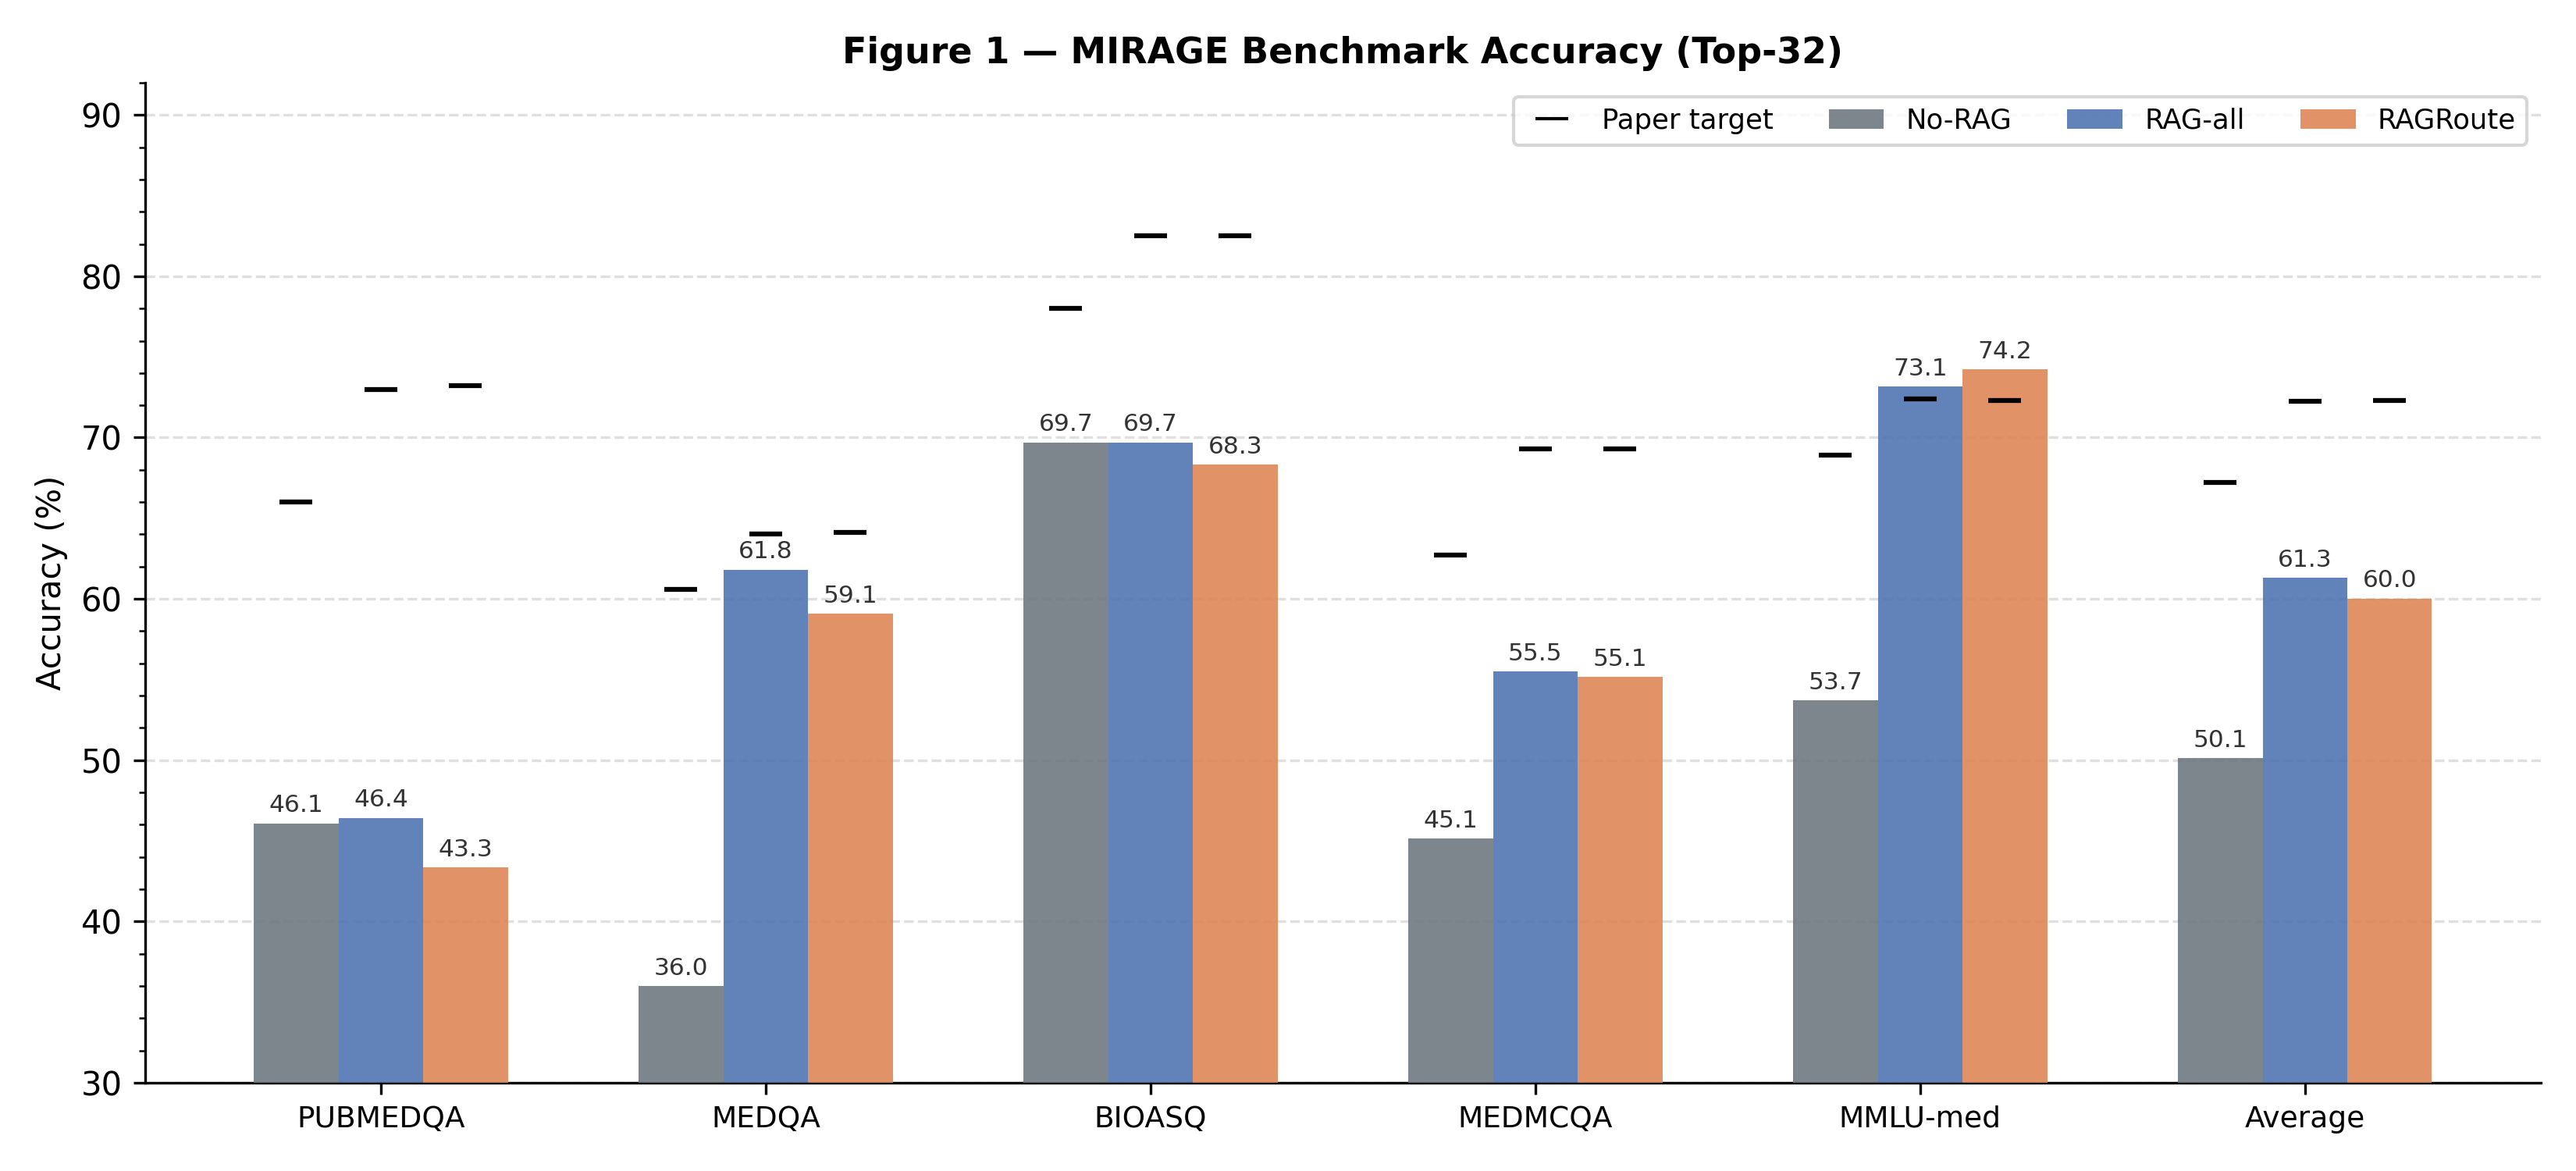

Figure 2 saved


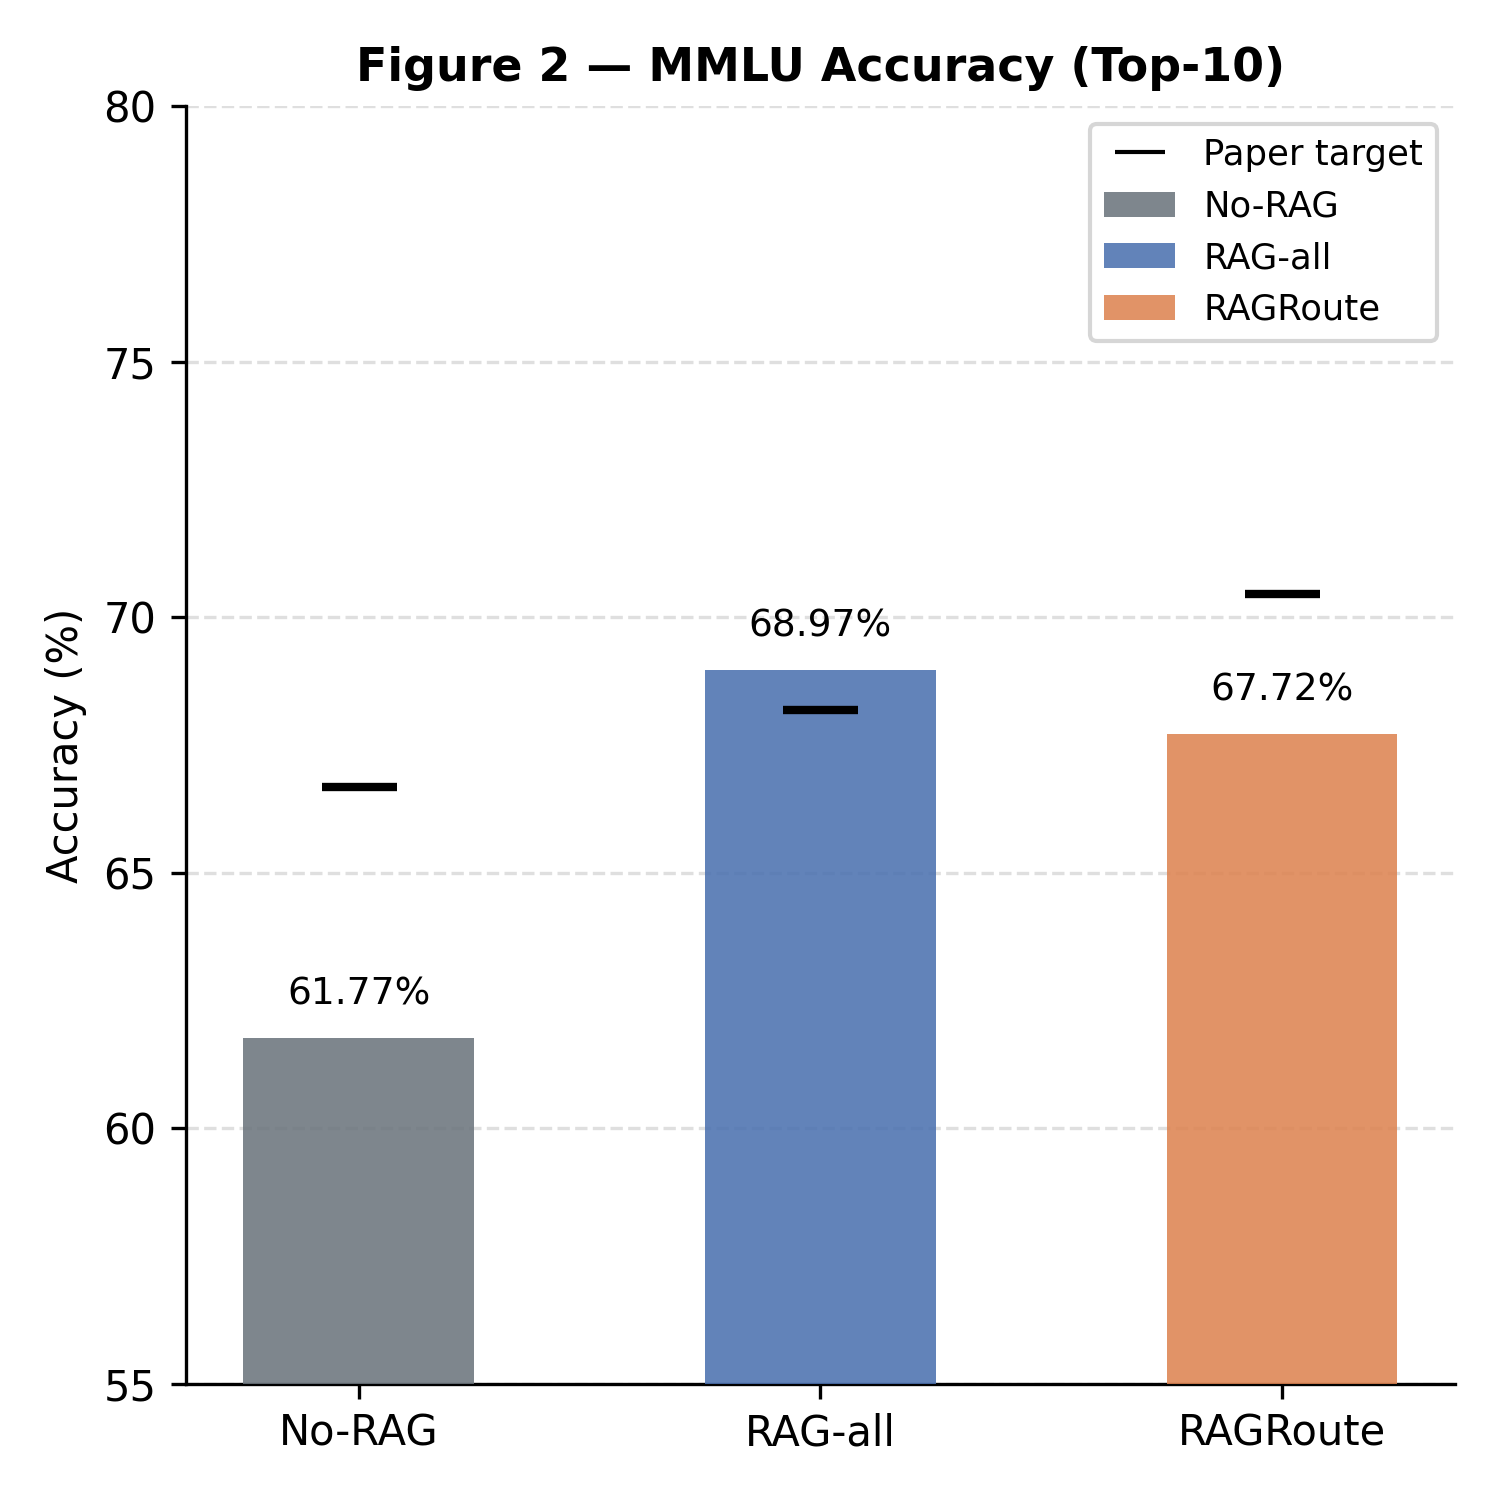

Figure 3 saved


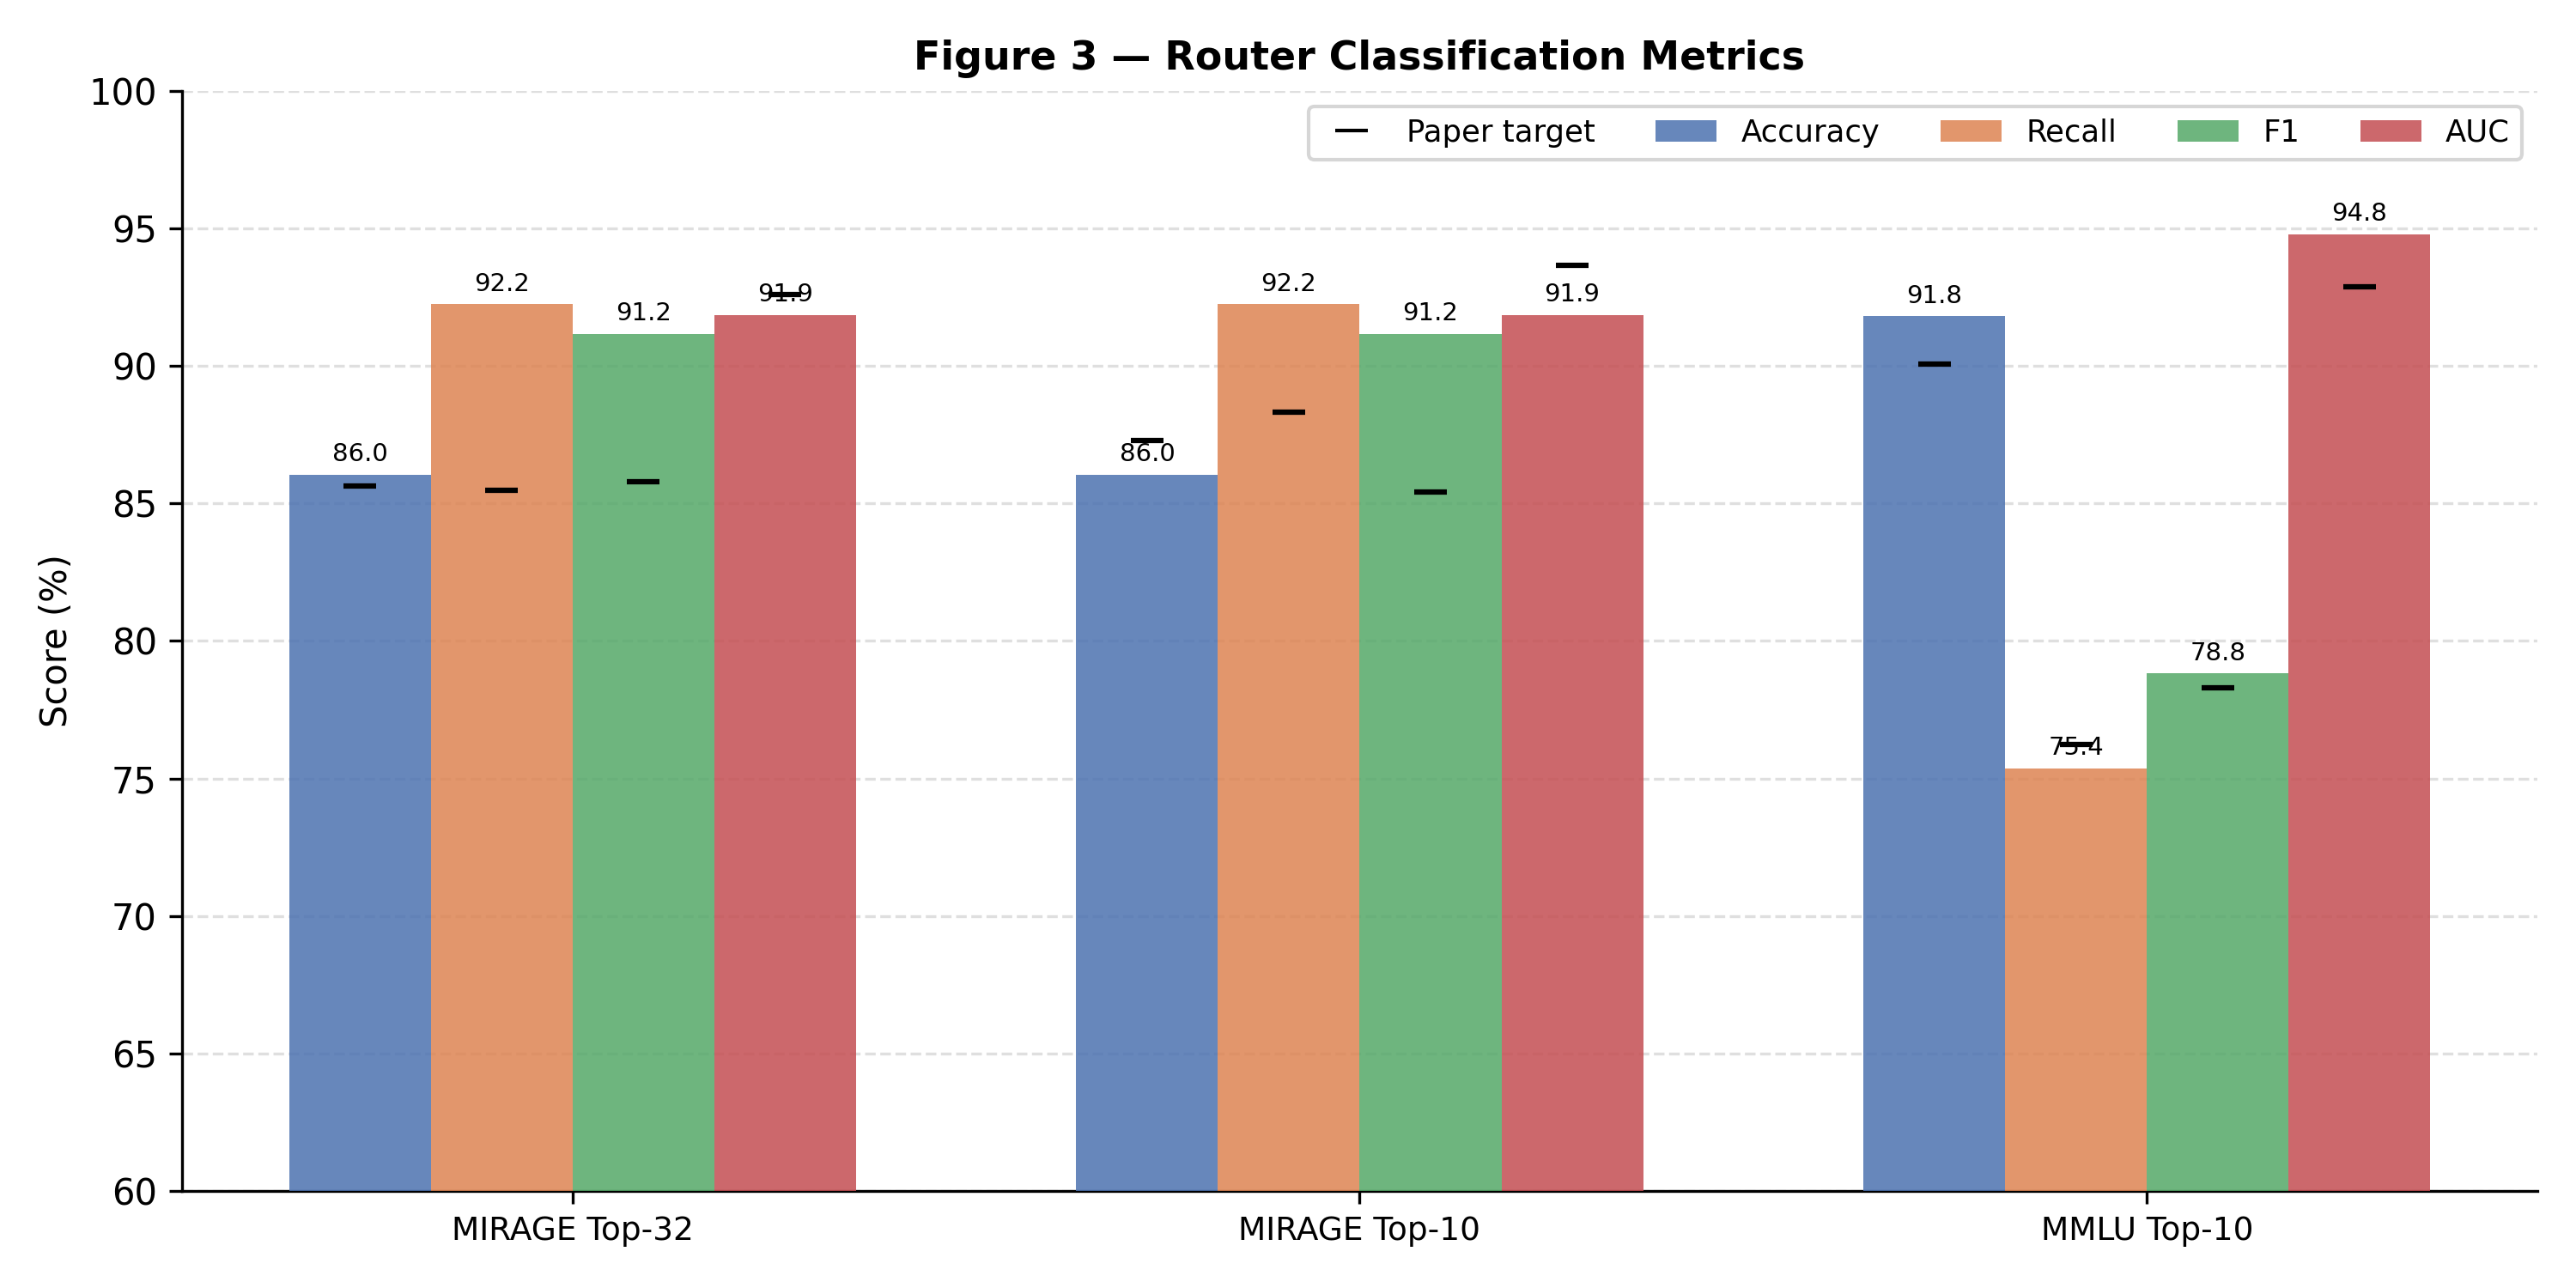

Figure 4 saved


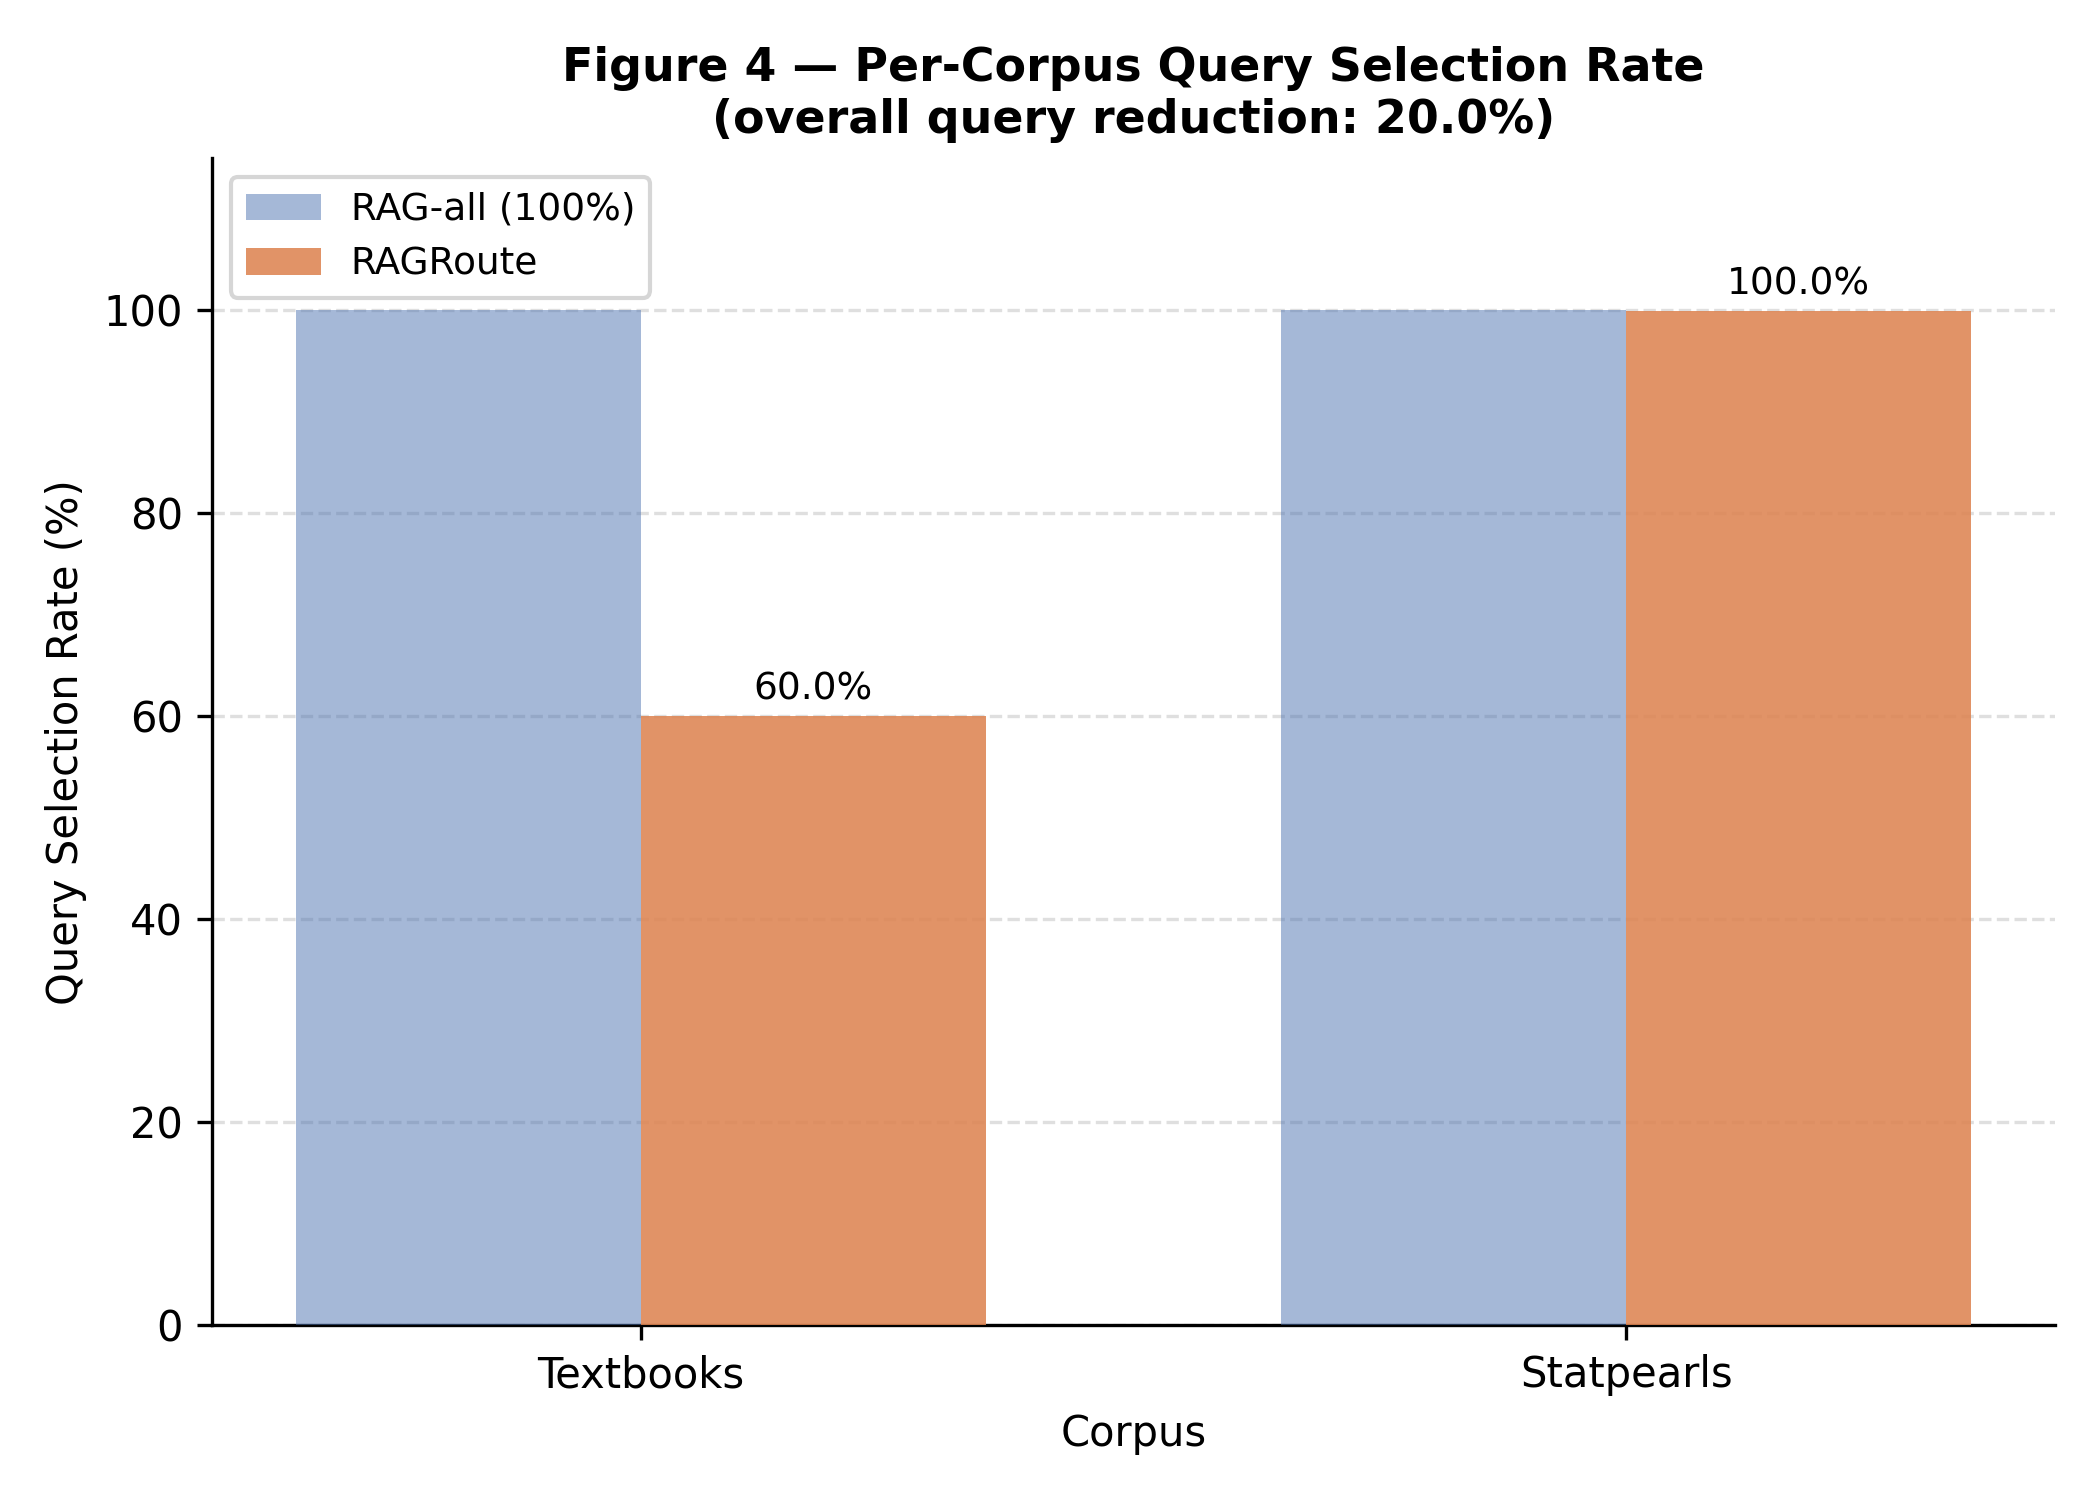

In [ ]:
import json, os, pickle
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
from src.config import INPUT_DIM, DATA_SOURCES, CHECKPOINT_DIR, RESULTS_DIR
from src.router_model import CorpusRoutingNN

os.makedirs('figures', exist_ok=True)

MIRAGE_BENCHMARKS = ['pubmedqa', 'medqa', 'bioasq', 'medmcqa', 'mmlu-med']
MODES       = ['no_rag', 'rag_all', 'ragroute']
MODE_LABELS = {'no_rag': 'No-RAG', 'rag_all': 'RAG-all', 'ragroute': 'RAGRoute'}
MODE_COLORS = {'no_rag': '#6c757d', 'rag_all': '#4c72b0', 'ragroute': '#dd8452'}

PAPER_TARGETS_MIRAGE = {
    'no_rag':   {'pubmedqa': 66.0,  'medqa': 60.6,  'bioasq': 78.0,  'medmcqa': 62.7, 'mmlu-med': 68.9},
    'rag_all':  {'pubmedqa': 73.0,  'medqa': 64.0,  'bioasq': 82.5,  'medmcqa': 69.3, 'mmlu-med': 72.4},
    'ragroute': {'pubmedqa': 73.2,  'medqa': 64.1,  'bioasq': 82.5,  'medmcqa': 69.3, 'mmlu-med': 72.3},
}
PAPER_TARGETS_MMLU = {'no_rag': 66.67, 'rag_all': 68.18, 'ragroute': 70.45}
MEDRAG_CORPORA = DATA_SOURCES['medrag']

def _load(mode, benchmark):
    p = f'{RESULTS_DIR}/{mode}_{benchmark}.json'
    return json.load(open(p)) if os.path.exists(p) else None

# ── Figure 1: MIRAGE accuracy ─────────────────────────────────────────────
categories = [b.upper() if b != 'mmlu-med' else 'MMLU-med' for b in MIRAGE_BENCHMARKS] + ['Average']
data  = {m: [] for m in MODES}
paper = {m: [] for m in MODES}
any_result = False
for mode in MODES:
    per = {b: _load(mode, b) for b in MIRAGE_BENCHMARKS}
    for b in MIRAGE_BENCHMARKS:
        r = per[b]
        data[mode].append(r['accuracy'] if r else None)
        paper[mode].append(PAPER_TARGETS_MIRAGE[mode].get(b))
        if r: any_result = True
    vals = [r['accuracy'] for r in per.values() if r]
    data[mode].append(float(np.mean(vals)) if vals else None)
    paper[mode].append(float(np.mean(list(PAPER_TARGETS_MIRAGE[mode].values()))))

if any_result:
    n_cat, n_mode, width = len(categories), len(MODES), 0.22
    x = np.arange(n_cat)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, mode in enumerate(MODES):
        offset = (i - (n_mode - 1) / 2) * width
        bars = ax.bar(x + offset, [v if v else 0 for v in data[mode]], width,
                      label=MODE_LABELS[mode], color=MODE_COLORS[mode], alpha=0.88, zorder=3)
        for bar, val in zip(bars, data[mode]):
            if val:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, f'{val:.1f}',
                        ha='center', va='bottom', fontsize=7.5, color='#333333')
        refs = paper[mode]
        for j, ref in enumerate(refs):
            if ref:
                ax.plot(x[j]+offset, ref, marker='_', color='black',
                        markersize=10, markeredgewidth=1.5, zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title('Figure 1 — MIRAGE Benchmark Accuracy (Top-32)', fontsize=11, fontweight='bold')
    ax.set_ylim(30, 92)
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(2))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.plot([], [], marker='_', color='black', linestyle='none', markersize=10, label='Paper target')
    ax.legend(fontsize=8.5, ncol=4)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig('figures/fig1_mirage_accuracy.png', dpi=300)
    plt.close(fig)
    print('Figure 1 saved')
    display(Image('figures/fig1_mirage_accuracy.png'))
else:
    print('[Fig 1] No results — run cell-eval-e2e first')

# ── Figure 2: MMLU accuracy ───────────────────────────────────────────────
mmlu_data = {m: _load(m, 'mmlu') for m in MODES}
if any(v for v in mmlu_data.values()):
    fig, ax = plt.subplots(figsize=(5, 5))
    x = np.arange(len(MODES))
    for i, mode in enumerate(MODES):
        r = mmlu_data[mode]
        val = r['accuracy'] if r else None
        ref = PAPER_TARGETS_MMLU[mode]
        ax.bar(i, val if val else 0, 0.5, color=MODE_COLORS[mode], alpha=0.88,
               label=MODE_LABELS[mode], zorder=3)
        if val:
            ax.text(i, val+0.5, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
        ax.plot(i, ref, marker='_', color='black', markersize=18, markeredgewidth=2, zorder=4)
    ax.set_xticks(x); ax.set_xticklabels([MODE_LABELS[m] for m in MODES], fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title('Figure 2 — MMLU Accuracy (Top-10)', fontsize=11, fontweight='bold')
    ax.set_ylim(55, 80)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.plot([], [], marker='_', color='black', linestyle='none', markersize=12, label='Paper target')
    ax.legend(fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig('figures/fig2_mmlu_accuracy.png', dpi=300)
    plt.close(fig)
    print('Figure 2 saved')
    display(Image('figures/fig2_mmlu_accuracy.png'))
else:
    print('[Fig 2] No MMLU results — run cell-eval-e2e first')

# ── Figure 3: Router classification metrics ───────────────────────────────
experiments = [
    ('MIRAGE Top-32', 'medrag',    'data/processed/mirage', 'medrag'),
    ('MIRAGE Top-10', 'medrag',    'data/processed/mirage', 'medrag'),
    ('MMLU Top-10',   'wikipedia', 'data/processed/mmlu',   'wikipedia'),
]
paper_cls = {
    'MIRAGE Top-32': (85.63, 85.47, 85.79, 92.60),
    'MIRAGE Top-10': (87.30, 88.32, 85.43, 93.67),
    'MMLU Top-10':   (90.06, 76.23, 78.29, 92.88),
}
metric_names  = ['Accuracy', 'Recall', 'F1', 'AUC']
metric_colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

cls_results = {}
any_cls = False
for label, dataset, proc_dir, ckpt in experiments:
    paths = [f'{proc_dir}/X_test.npy', f'{proc_dir}/y_test.npy',
             f'checkpoints/{ckpt}_model_best.pth', f'checkpoints/{ckpt}_scaler.pkl']
    if not all(os.path.exists(p) for p in paths):
        cls_results[label] = None; continue
    X = np.load(paths[0]).astype(np.float32)
    y = np.load(paths[1])
    mdl = CorpusRoutingNN(INPUT_DIM[dataset])
    mdl.load_state_dict(torch.load(paths[2], map_location='cpu', weights_only=True))
    mdl.eval()
    with open(paths[3], 'rb') as fh: sc = pickle.load(fh)
    X = sc.transform(X).astype(np.float32)
    with torch.no_grad(): probs = torch.sigmoid(mdl(torch.tensor(X)).squeeze(1)).numpy()
    pred = (probs >= 0.5).astype(int)
    cls_results[label] = (
        accuracy_score(y, pred)*100,
        recall_score(y, pred, zero_division=0)*100,
        f1_score(y, pred, zero_division=0)*100,
        roc_auc_score(y, probs)*100 if len(np.unique(y))>1 else float('nan'),
    )
    any_cls = True

if any_cls:
    exp_labels = [e[0] for e in experiments]
    x = np.arange(len(exp_labels))
    width = 0.18
    fig, ax = plt.subplots(figsize=(10, 5))
    for j, (metric, color) in enumerate(zip(metric_names, metric_colors)):
        vals = [cls_results[l][j] if cls_results[l] else None for l in exp_labels]
        refs = [paper_cls[l][j] for l in exp_labels]
        offset = (j - (len(metric_names)-1)/2) * width
        bars = ax.bar(x+offset, [v if v else 0 for v in vals], width,
                      label=metric, color=color, alpha=0.85, zorder=3)
        for bar, val in zip(bars, vals):
            if val is not None:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7)
        for k, ref in enumerate(refs):
            ax.plot(x[k]+offset, ref, marker='_', color='black',
                    markersize=9, markeredgewidth=1.5, zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(exp_labels, fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=10)
    ax.set_title('Figure 3 — Router Classification Metrics', fontsize=11, fontweight='bold')
    ax.set_ylim(60, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.plot([], [], marker='_', color='black', linestyle='none', markersize=9, label='Paper target')
    ax.legend(fontsize=8.5, ncol=5)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig('figures/fig3_classification_metrics.png', dpi=300)
    plt.close(fig)
    print('Figure 3 saved')
    display(Image('figures/fig3_classification_metrics.png'))
else:
    print('[Fig 3] No checkpoints — run cell-train first')

# ── Figure 4: Query reduction ─────────────────────────────────────────────
corpus_selected = {c: 0 for c in MEDRAG_CORPORA}
n_total = 0
for b in MIRAGE_BENCHMARKS:
    r = _load('ragroute', b)
    if not r: continue
    for rec in r.get('records', []):
        n_total += 1
        for src in rec.get('selected_sources', []):
            if src in corpus_selected: corpus_selected[src] += 1

if n_total > 0:
    rates = [corpus_selected[c] / n_total * 100 for c in MEDRAG_CORPORA]
    x = np.arange(len(MEDRAG_CORPORA))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(x - width/2, [100]*len(MEDRAG_CORPORA), width, label='RAG-all (100%)',
           color='#4c72b0', alpha=0.5, zorder=3)
    bars = ax.bar(x + width/2, rates, width, label='RAGRoute',
                  color='#dd8452', alpha=0.88, zorder=3)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    overall = (1 - sum(corpus_selected.values())/(n_total*len(MEDRAG_CORPORA))) * 100
    ax.set_xlabel('Corpus', fontsize=10)
    ax.set_ylabel('Query Selection Rate (%)', fontsize=10)
    ax.set_title(f'Figure 4 — Per-Corpus Query Selection Rate\n(overall query reduction: {overall:.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([c.capitalize() for c in MEDRAG_CORPORA], fontsize=10)
    ax.set_ylim(0, 115)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig('figures/fig4_query_reduction.png', dpi=300)
    plt.close(fig)
    print('Figure 4 saved')
    display(Image('figures/fig4_query_reduction.png'))
else:
    print('[Fig 4] No ragroute records — run cell-eval-e2e first')


In [ ]:
# -- 11. 단위 테스트 ------------------------------------------------------
# 전체 테스트 출력이 길어도 실패 원인을 숨기지 않도록 tail을 쓰지 않습니다.
!python -m pytest tests/ -v --tb=short


In [ ]:
import os, sys, shutil, subprocess
from google.colab import drive, userdata

REPO_URL   = 'https://github.com/ByoungjaeMin/ragroute_recreation.git'
REPO_PATH  = '/content/ragroute_recreation'
DRIVE_ROOT = '/content/drive/MyDrive/ragroute'

drive.mount('/content/drive')

# 런타임 재시작 시 repo가 사라지므로 없으면 재클론
if not os.path.isdir(REPO_PATH):
    subprocess.run(['git', 'clone', REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(['git', '-C', REPO_PATH, 'pull', '--ff-only'])

os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH)

hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = os.environ['HUGGING_FACE_HUB_TOKEN'] = hf_token

subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)

def _link(local, sub):
    d = f'{DRIVE_ROOT}/{sub}'; os.makedirs(d, exist_ok=True)
    parent = os.path.dirname(local)
    if parent: os.makedirs(parent, exist_ok=True)
    if os.path.islink(local): os.remove(local)
    elif os.path.isdir(local): shutil.rmtree(local)
    os.symlink(d, local)

for local, sub in [('data/embeddings','embeddings'), ('data/processed','processed'),
                   ('data/stats','stats'), ('data/raw','raw'),
                   ('checkpoints','checkpoints'), ('results','results')]:
    _link(local, sub)

print('복구 완료 — 완료된 단계 이후 셀부터 재개하세요')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
복구 완료 — 완료된 단계 이후 셀부터 재개하세요


In [ ]:
from google.colab import runtime
runtime.unassign()
